<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Datos_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datos - Laboratorio N°1

In [48]:
# @title Importación, visualización, manipulación de datos
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle
import time
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score,
                              ConfusionMatrixDisplay, make_scorer)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance




---


## Experiencia 2: Monitor de calidad de aire en espacios de trabajo

  
**Dataset:** `datos_adl.csv`  

**Grupo 8:** — Alex Nahuel Acosta, Santiago Daniel Bareiro, Agustín Marcelo Borges

**Fecha:** — xx/04/2026

---

> Dispositivo IoT embebido de bajo costo para clasificación autónoma de situaciones de riesgo en ambientes cerrados.

---

### 0. Carga y exploración de datos

In [49]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
!wget https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv

--2026-04-08 13:44:18--  https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54724 (53K) [text/plain]
Saving to: ‘datos_adl.csv.1’

datos_adl.csv.1     100%[===================>]  53.44K  --.-KB/s    in 0.01s   

2026-04-08 13:44:18 (4.96 MB/s) - ‘datos_adl.csv.1’ saved [54724/54724]



In [50]:
# Lectura del dataset
dataset_adl = pd.read_csv("datos_adl.csv")
dataset_adl

,MQ2,MQ9,MQ135,MQ137,MQ138,MG-811,Situacion
0,670,696,1252,1720,1321,2431,4
1,641,674,1156,1652,1410,2433,4
2,642,646,1159,1643,1455,2361,4
3,640,590,1105,1608,1459,2427,4
4,616,627,1192,1637,1466,2447,4
...,...,...,...,...,...,...,...
1840,862,826,1564,1768,1540,2037,4
1841,917,821,1571,1779,1543,2008,4
1842,925,832,1582,1776,1545,1989,4
1843,928,840,1587,1787,1538,1986,4


In [51]:
dataset_adl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1845 entries, 0 to 1844
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   MQ2        1845 non-null   int64
 1   MQ9        1845 non-null   int64
 2   MQ135      1845 non-null   int64
 3   MQ137      1845 non-null   int64
 4   MQ138      1845 non-null   int64
 5   MG-811     1845 non-null   int64
 6   Situacion  1845 non-null   int64
dtypes: int64(7)
memory usage: 101.0 KB


No hay valores nulos, todos los datos son de tipo entero, la dataset pesa 101 KB

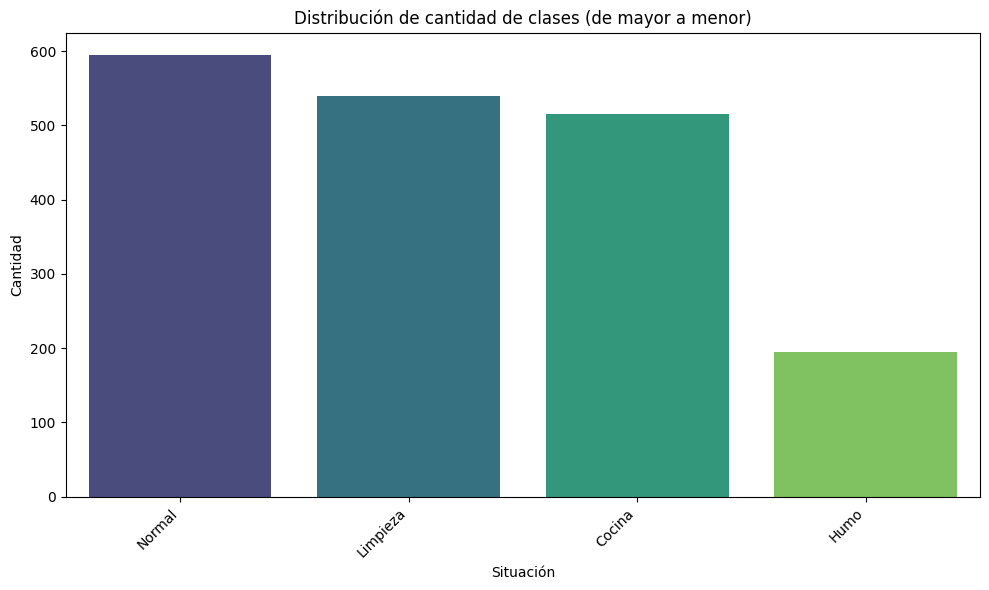

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

situacion_counts = dataset_adl['Situacion'].value_counts().sort_values(ascending=False)

situacion_labels = {
    1: 'Normal',
    2: 'Cocina',
    3: 'Humo',
    4: 'Limpieza'
}

# Map numerical situations to their descriptive labels for plotting
labels = [situacion_labels[s] for s in situacion_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=situacion_counts.values, hue=labels, palette='viridis', legend=False)
plt.title('Distribución de cantidad de clases (de mayor a menor)')
plt.xlabel('Situación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [67]:
situacion_counts = dataset_adl['Situacion'].value_counts()
total_instances = situacion_counts.sum()

situacion_labels = {
    1: 'Normal',
    2: 'Cocina',
    3: 'Humo',
    4: 'Limpieza'
}

percentages = (situacion_counts / total_instances) * 100

print("Porcentaje de cada clase:")
for situacion_id, count in situacion_counts.items():
    label = situacion_labels.get(situacion_id, f'Situacion {situacion_id}')
    percentage = percentages[situacion_id]
    print(f"- {label}: {percentage:.2f}%")

Porcentaje de cada clase:
- Normal: 32.25%
- Limpieza: 29.27%
- Cocina: 27.91%
- Humo: 10.57%


Hay un claro desbalance de clases, la de humo posee 3 veces menos muestras que la normal.